## Importanto os dados de treino e teste

In [1]:
import joblib

In [ ]:
X_tr, X_te, y_tr, y_te = joblib.load('./dados_preparados.pkl')

## Importando os transformers

In [ ]:
configs = joblib.load('./transformers.pkl')
print(type(configs))

<class 'dict'>


## Imports

In [5]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate

# Treinamento dos modelos

## Regressão Logística

Treinamento do modelo com as diferentes column transformers e combinações:
- txt_word - TF-IDF para palavras, com unigramas e bigramas
- txt_word + txt_char - TF-IDF para caracteres, com trigramas a quiquigramas
- txt_word + meta - TF-IDF para palavras e metadados estilométricos
- txt_word + txt_char + meta - Todos os passos combinados

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict, cross_validate
'''
scoring = ["f1_macro", "accuracy", "precision_macro", "recall_macro"]
resultados = []

print("Logistic Regression")
for nome, transformers in configs.items():
    pipe = Pipeline(
        [
            ("prep", ColumnTransformer(transformers)),
            (
                "clf",
                LogisticRegression(max_iter=1000, class_weight="balanced"),
            ),
        ]
    )

    # 1. Executa o cross_validate padrão para as métricas do seu relatório
    cv = cross_validate(pipe, X_tr, y_tr, cv=5, scoring=scoring)
    print(f"\n{nome}")

    linha = {"config": nome}
    for m in scoring:
        vals = cv[f"test_{m}"]
        print(f"  {m}: {vals.mean():.4f} ± {vals.std():.4f}")
        linha[f"{m}_mean"] = vals.mean()
        linha[f"{m}_std"] = vals.std()

    resultados.append(linha)

    # Matriz de confusão
    y_pred_cv = cross_val_predict(pipe, X_tr, y_tr, cv=5)

    cm = confusion_matrix(y_tr, y_pred_cv)

    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusão: {nome}")
    plt.show()
    '''


Logistic Regression

word
  f1_macro: 0.9243 ± 0.0048
  accuracy: 0.9243 ± 0.0048
  precision_macro: 0.9250 ± 0.0044
  recall_macro: 0.9243 ± 0.0048


KeyboardInterrupt: 

              precision    recall  f1-score   support

           0     0.9222    0.9708    0.9459       720
           1     0.9692    0.9181    0.9429       720

    accuracy                         0.9444      1440
   macro avg     0.9457    0.9444    0.9444      1440
weighted avg     0.9457    0.9444    0.9444      1440

ROC-AUC: 0.986983024691358


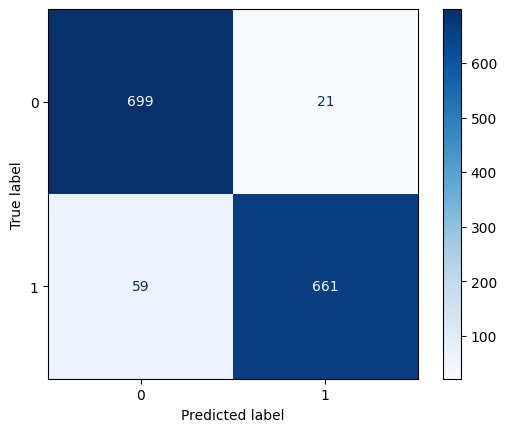

In [8]:
import numpy as np
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score)

pipe_final = Pipeline([
    ("prep", ColumnTransformer(configs['word+char'])),
    (
                "clf",
                LogisticRegression(max_iter=1000, class_weight="balanced"),
            ),
])
pipe_final.fit(X_tr, y_tr)

y_pred = pipe_final.predict(X_te)
print(classification_report(y_te, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap="Blues")

# LinearSVC não tem predict_proba; para AUC use decision_function
print("ROC-AUC:", roc_auc_score(y_te, pipe_final.decision_function(X_te)))

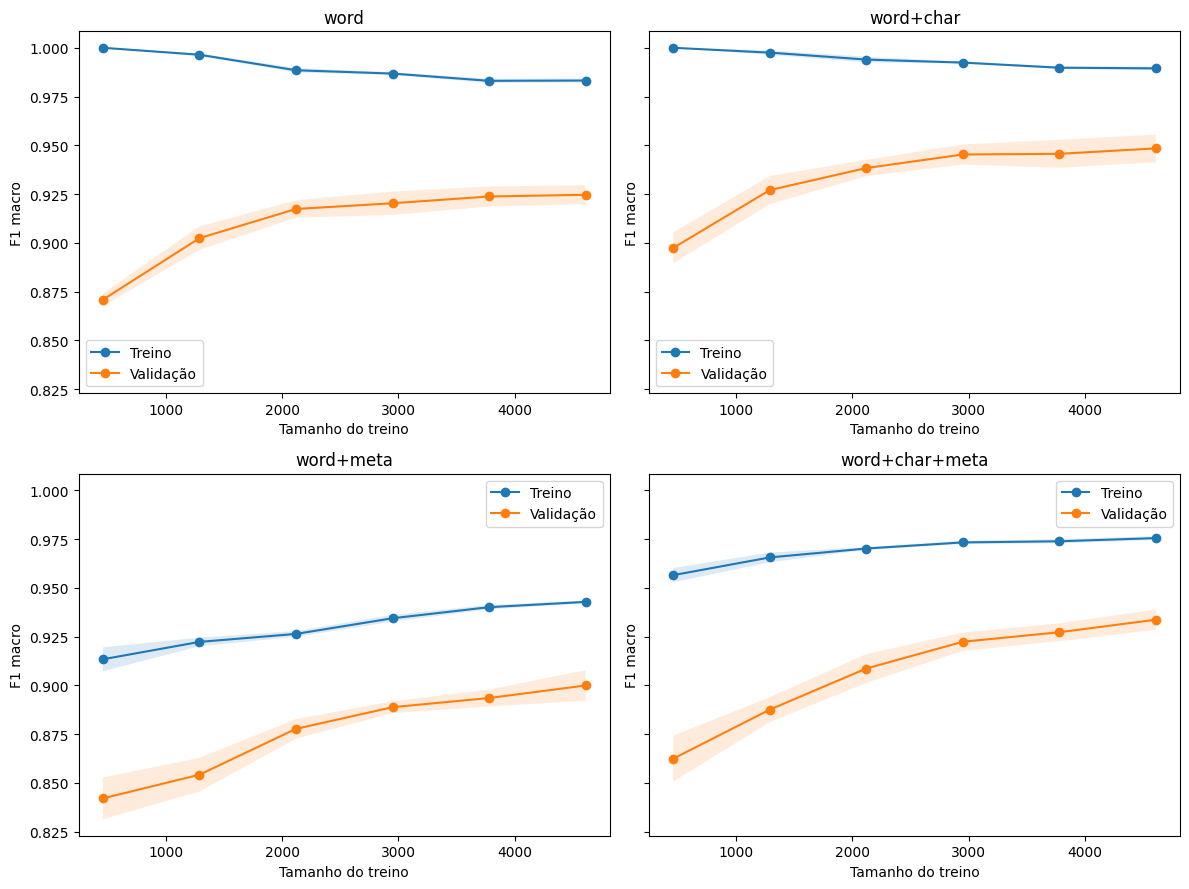

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

for ax, (nome, transformers) in zip(axes.ravel(), configs.items()):
    pipe = Pipeline([
        ("prep", ColumnTransformer(transformers)),
        (
                "clf",
                LogisticRegression(max_iter=1000, class_weight="balanced"),
            ),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_tr, y_tr,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=cv_lc,
        scoring="f1_macro",
        n_jobs=-1,
    )

    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, tr_m, "o-", label="Treino")
    ax.plot(train_sizes, va_m, "o-", label="Validação")
    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15)
    ax.set_title(nome)
    ax.set_xlabel("Tamanho do treino")
    ax.set_ylabel("F1 macro")
    ax.legend()

plt.tight_layout()
plt.show()

# Analise do TF-IDF

## TF-IDF do pipeline com Regressão Logística

In [10]:
# 0. Criando o pipeline da LR
pipe_lr = Pipeline([("prep", ColumnTransformer(configs["word"])),
                       ("clf", LogisticRegression(max_iter=1000))])

# 1. Treina o pipeline inteiro (prep + clf)
pipe_lr.fit(X_tr, y_tr)

# 2. Extrai o TfidfVectorizer JÁ TREINADO de dentro do ColumnTransformer
vetorizador = pipe_lr.named_steps["prep"].named_transformers_["txt_word"]

# 3. Transforma o teste com o vocabulário que o pipeline realmente aprendeu
matriz_tfidf = vetorizador.transform(X_te["texto_trunc"])

# 4. Monta o DataFrame com os termos reais
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vetorizador.get_feature_names_out(),
    index=X_te.index
)

# 5. Filtra colunas zeradas no teste
df_filtrado = df_tfidf.loc[:, (df_tfidf != 0).any(axis=0)]

print(df_filtrado.head())

      abafar  abaixo  abaixo abaixo  abaixo alguns  abaixo as  \
6660     0.0     0.0            0.0            0.0        0.0   
5627     0.0     0.0            0.0            0.0        0.0   
6706     0.0     0.0            0.0            0.0        0.0   
424      0.0     0.0            0.0            0.0        0.0   
4052     0.0     0.0            0.0            0.0        0.0   

      abaixo assinado  abaixo cbn  abaixo comentário  abaixo como  abaixo da  \
6660              0.0         0.0                0.0          0.0        0.0   
5627              0.0         0.0                0.0          0.0        0.0   
6706              0.0         0.0                0.0          0.0        0.0   
424               0.0         0.0                0.0          0.0        0.0   
4052              0.0         0.0                0.0          0.0        0.0   

      ...  única dos  única mulher  únicas  único  único de  único que  \
6660  ...        0.0           0.0     0.0    0.0     

## Heatmap dos termos mais relevantes

In [11]:
import shap
import seaborn as sns
import matplotlib.pyplot as plt

# Identifica os 20 termos com maior média de TF-IDF
top_20_termos = df_filtrado.mean().sort_values(ascending=False).head(20).index

# Filtra a matriz do DataFrame apenas com esses termos principais
df_heatmap = df_filtrado[top_20_termos]


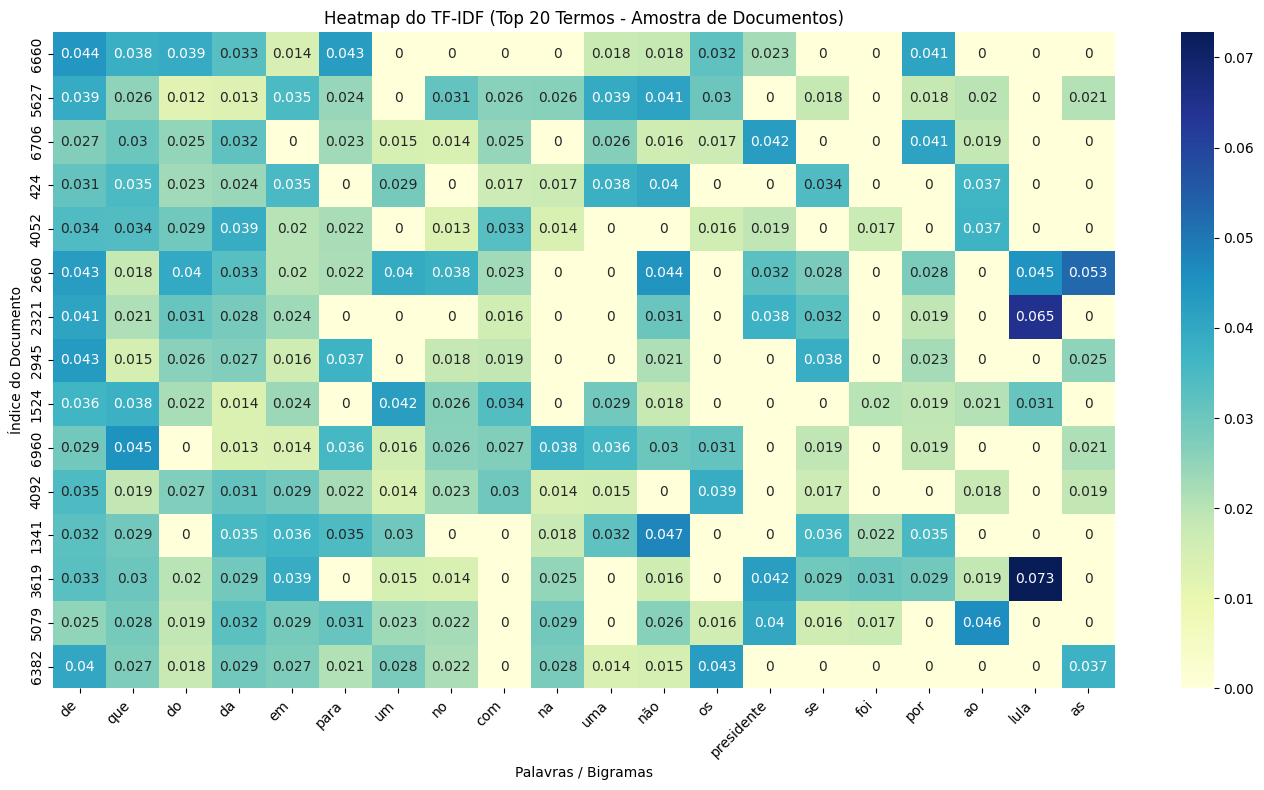

In [12]:
plt.figure(figsize=(14, 8))
# Amostra das primeiras 15 linhas para não sobrecarregar o gráfico
sns.heatmap(df_heatmap.head(15), annot=True, cmap="YlGnBu", cbar=True)

plt.title("Heatmap do TF-IDF (Top 20 Termos - Amostra de Documentos)")
plt.xlabel("Palavras / Bigramas")
plt.ylabel("Índice do Documento")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Shap com os termos que mais impactam

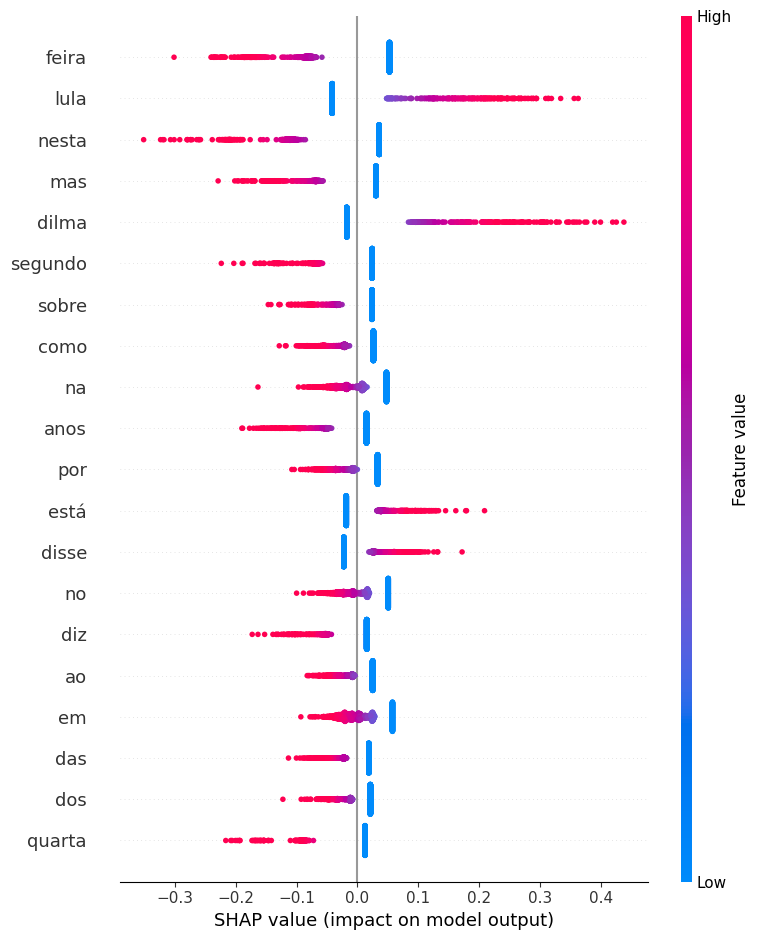

In [13]:
# 1. Recupera o classificador treinado do pipeline
modelo_lr = pipe_lr.named_steps['clf']

# 2. Como a Regressão Logística é um modelo linear, usamos o LinearExplainer
# Usamos a matriz TF-IDF completa do conjunto de teste convertida para array
explainer = shap.LinearExplainer(modelo_lr, df_tfidf.values, feature_names=df_tfidf.columns.tolist())
shap_values = explainer(df_tfidf.values)

# 3. Gráfico de Resumo (Summary Plot) das palavras que mais impactam o modelo
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, df_tfidf.values, feature_names=df_tfidf.columns.tolist(), max_display=20)


## Heatmap da matriz de correlação

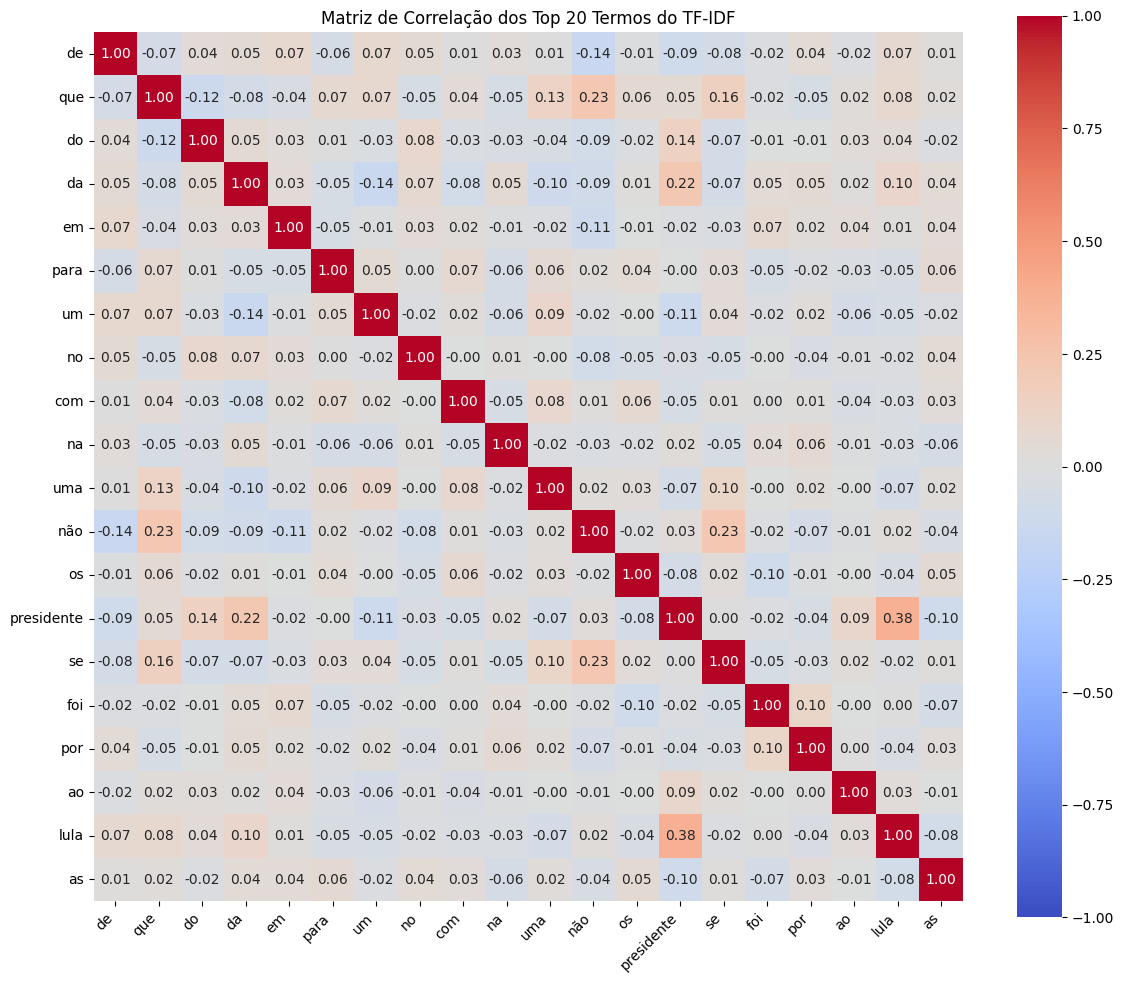

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcula a matriz de correlação (Pearson) apenas para os termos principais
matriz_corr = df_filtrado[top_20_termos].corr()

# 2. Configura e plota o Heatmap de Correlação
plt.figure(figsize=(12, 10))

# Usamos o mapa de cores 'coolwarm' porque ele destaca o que é positivo (vermelho) e negativo (azul)
sns.heatmap(
    matriz_corr,
    annot=True,          # Mostra os números de correlação dentro dos quadrados
    fmt=".2f",           # Limita a duas casas decimais
    cmap="coolwarm",     # Ideal para correlação (-1 a 1)
    vmin=-1, vmax=1,     # Força a escala a ir de -1 a 1
    square=True          # Deixa os quadrados perfeitamente simétricos
)

plt.title("Matriz de Correlação dos Top 20 Termos do TF-IDF")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## SHAP Value separado em Verdadeiros e Reais

In [15]:
# Adiciona a label ao DataFrame do TF-IDF usando o índice alinhado
df_filtrado_com_y = df_filtrado.copy()
df_filtrado_com_y["label_real"] = y_te.loc[df_filtrado.index]

# Divide o dataset entre y = 0 e y = 1
df_y0 = df_filtrado_com_y[df_filtrado_com_y["label_real"] == 0].drop(columns=["label_real"])
df_y1 = df_filtrado_com_y[df_filtrado_com_y["label_real"] == 1].drop(columns=["label_real"])


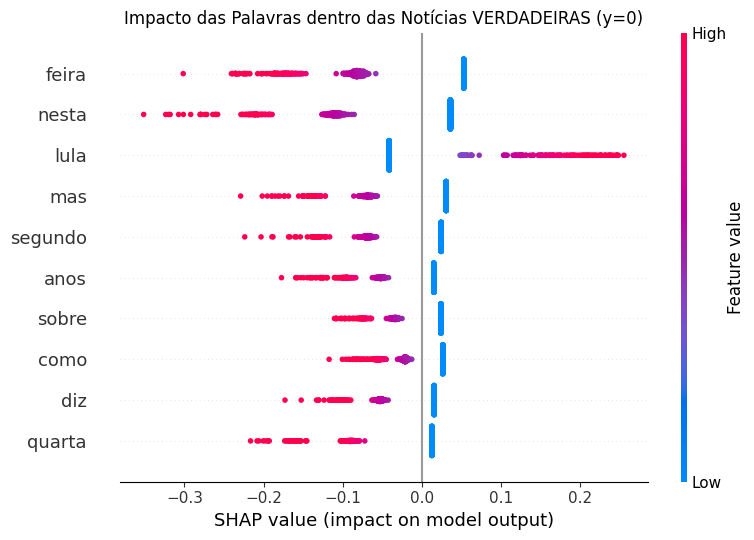

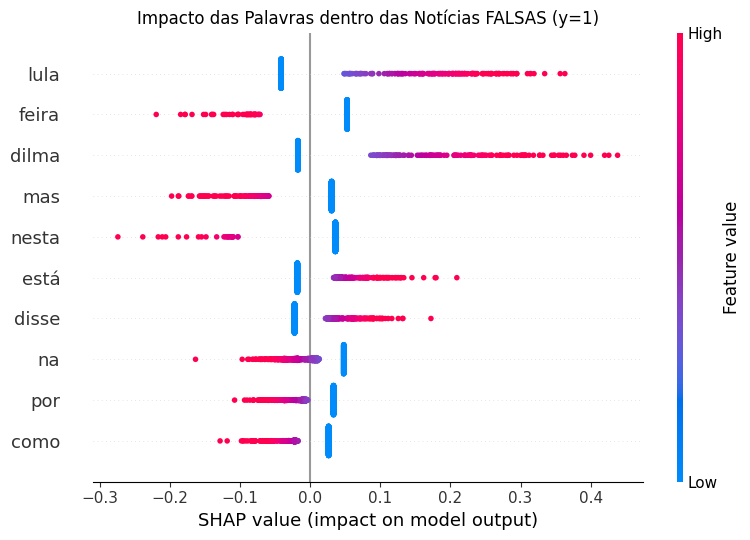

In [16]:
import shap
import matplotlib.pyplot as plt

# 1. Recupera os componentes do seu pipeline treinado
modelo_lr = pipe_lr.named_steps['clf']
vetorizador = pipe_lr.named_steps["prep"].named_transformers_["txt_word"]
nomes_features = vetorizador.get_feature_names_out().tolist()

# 2. Cria o explicador linear para o dataset completo
explainer = shap.LinearExplainer(modelo_lr, matriz_tfidf.toarray(), feature_names=nomes_features)

# 3. Separa os índices das notícias falsas (y=0) e verdadeiras (y=1) baseado no seu y_te
indices_falsas = y_te[y_te == 0].index
indices_verdadeiras = y_te[y_te == 1].index

# 4. Filtra as matrizes TF-IDF correspondentes a cada classe
X_falsas_tfidf = df_tfidf.loc[indices_falsas].values
X_verdadeiras_tfidf = df_tfidf.loc[indices_verdadeiras].values

# 5. Calcula os valores SHAP específicos para cada grupo de notícias
shap_falsas = explainer(X_falsas_tfidf)
shap_verdadeiras = explainer(X_verdadeiras_tfidf)

# --- PLOTAGEM DOS GRÁFICOS ---

# Gráfico 1: O que impacta dentro das Notícias Falsas (y = 0)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_falsas, X_falsas_tfidf, feature_names=nomes_features, max_display=10, show=False)
plt.title("Impacto das Palavras dentro das Notícias VERDADEIRAS (y=0)")
plt.tight_layout()
plt.show()

# Gráfico 2: O que impacta dentro das Notícias Verdadeiras (y = 1)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_verdadeiras, X_verdadeiras_tfidf, feature_names=nomes_features, max_display=10, show=False)
plt.title("Impacto das Palavras dentro das Notícias FALSAS (y=1)")
plt.tight_layout()
plt.show()
